In [5]:
   !pip install kaggle pandas matplotlib seaborn --quiet 


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [7]:
student_name = "Joyce Anne Jano"
student_id = "TUPM-25-1312"

id_num = 1312

color1 = f"#{(id_num * 7) % 256:02x}{(id_num * 3) % 256:02x}{(id_num * 5) % 256:02x}"

color2 = f"#{(id_num * 2) % 256:02x}{(id_num * 9) % 256:02x}{(id_num * 4) % 256:02x}"

In [8]:
!kaggle datasets download -d kunalgp/top-1000-most-played-spotify-songs-of-all-time -p spotify_dataset --unzip

Dataset URL: https://www.kaggle.com/datasets/kunalgp/top-1000-most-played-spotify-songs-of-all-time
License(s): CC0-1.0




  0%|          | 0.00/52.0k [00:00<?, ?B/s]
100%|██████████| 52.0k/52.0k [00:00<00:00, 434kB/s]
100%|██████████| 52.0k/52.0k [00:00<00:00, 431kB/s]


In [9]:
import os
print(os.listdir("spotify_dataset"))

['spotify_top_1000_tracks.csv']


In [10]:
import pandas as pd

df = pd.read_csv("spotify_dataset/spotify_top_1000_tracks.csv")
print(df.head())

                 track_name          artist  \
0  All The Stars (with SZA)  Kendrick Lamar   
1                   Starboy      The Weeknd   
2                  Señorita    Shawn Mendes   
3                Heat Waves   Glass Animals   
4           Let Me Love You        DJ Snake   

                                               album release_date  popularity  \
0  Black Panther The Album Music From And Inspire...   2018-02-09          95   
1                                            Starboy   2016-11-25          90   
2                                           Señorita   2019-06-21          80   
3                                          Dreamland   2020-08-07          87   
4                                             Encore   2016-08-05          87   

                                         spotify_url                      id  \
0  https://open.spotify.com/track/3GCdLUSnKSMJhs4...  3GCdLUSnKSMJhs4Tj6CV3s   
1  https://open.spotify.com/track/7MXVkk9YMctZqd1...  7MXVkk9YMctZqd1S

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [12]:
# Step 1: Install libraries
!pip install kaggle pandas matplotlib seaborn --quiet

# Step 2: Import OS
import os

# Step 3: Ensure Kaggle directory exists
kaggle_dir = os.path.expanduser("~/.kaggle")
if not os.path.exists(kaggle_dir):
    os.makedirs(kaggle_dir)

# Step 4: Download and unzip dataset
!kaggle datasets download -d kunalgp/top-1000-most-played-spotify-songs-of-all-time -p spotify_dataset --unzip

# Step 5: Confirm files
print("Files in directory:", os.listdir("spotify_dataset"))


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Dataset URL: https://www.kaggle.com/datasets/kunalgp/top-1000-most-played-spotify-songs-of-all-time
License(s): CC0-1.0

Files in directory: ['spotify_top_1000_tracks.csv']



  0%|          | 0.00/52.0k [00:00<?, ?B/s]
100%|██████████| 52.0k/52.0k [00:00<00:00, 293kB/s]
100%|██████████| 52.0k/52.0k [00:00<00:00, 292kB/s]


In [13]:
print(df.columns)

Index(['track_name', 'artist', 'album', 'release_date', 'popularity',
       'spotify_url', 'id', 'duration_min'],
      dtype='str')


In [14]:
import pandas as pd
import numpy as np

# Clean up text columns
df['track_name'] = df['track_name'].str.strip()

df['artist'] = df['artist'].str.strip()

df['album'] = df['album'].str.strip()

# Convert release_date to datetime
df['release_date'] = pd.to_datetime(
    df['release_date'],
    errors='coerce'
)

# Create year column from release_date
df['year'] = df['release_date'].dt.year

# Fill missing years
df['year'] = df['year'].fillna(0).astype(int)

# Drop unnecessary columns
cols_to_drop = ['spotify_url', 'id']

if 'time_signature' in df.columns:
    cols_to_drop.append('time_signature')

if 'key' in df.columns:
    cols_to_drop.append('key')

if 'mode' in df.columns:
    cols_to_drop.append('mode')

df = df.drop(columns=cols_to_drop, errors='ignore')

# Tempo category
if 'tempo' in df.columns:

    tempo_bins = [0, 100, 140, np.inf]

    tempo_labels = ['Slow', 'Medium', 'Fast']

    df['tempo_category'] = pd.cut(
        df['tempo'],
        bins=tempo_bins,
        labels=tempo_labels,
        right=False
    )

    print("Feature 'tempo_category' created.")

else:
    print("Warning: 'tempo' column not found.")

# Remove duplicates
df = df.drop_duplicates(
    subset=['track_name', 'artist'],
    keep='first'
)

print("Data cleaning and feature engineering complete.")

print("Final Row Count:", len(df))

Data cleaning and feature engineering complete.
Final Row Count: 971


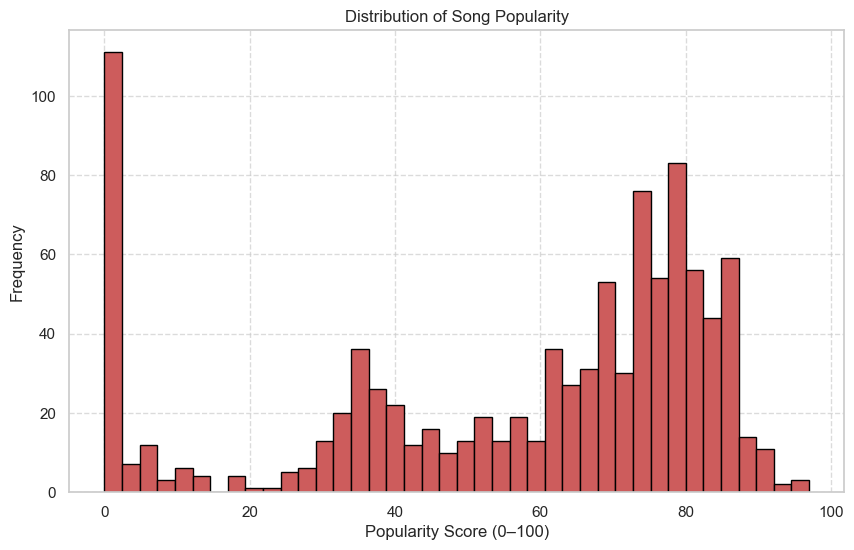

In [15]:
# 1. HISTOGRAM

plt.figure(figsize=(10, 6))
plt.hist(df['popularity'], bins=40, color='indianred', edgecolor='black')
plt.title('Distribution of Song Popularity')
plt.xlabel('Popularity Score (0–100)')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

C:\Users\joyce\AppData\Local\Temp\ipykernel_44228\1670566226.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='year', y='popularity', data=df, palette='viridis')


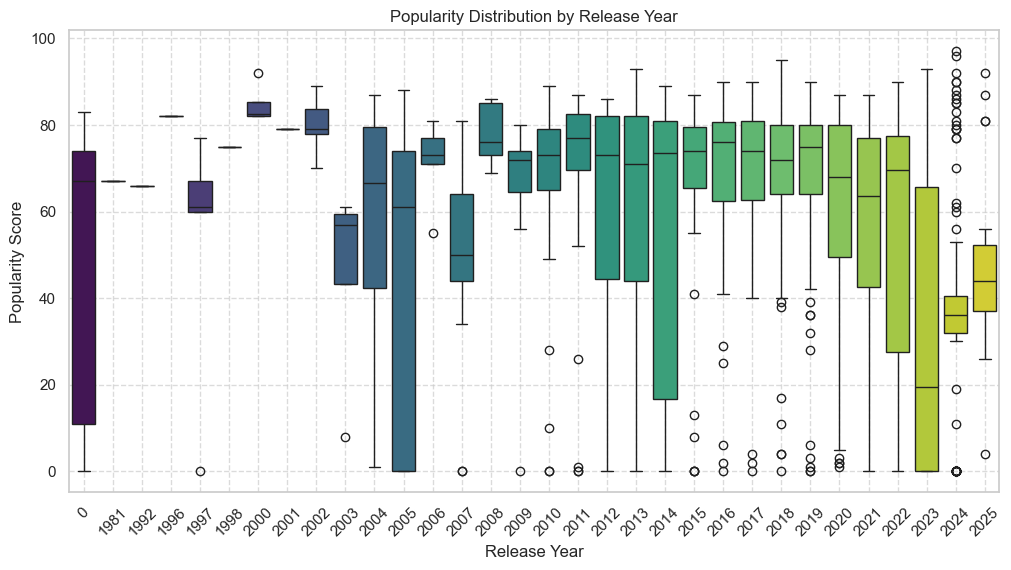

In [16]:
# 2. BOXPLOT

import seaborn as sns

plt.figure(figsize=(12, 6))
sns.boxplot(x='year', y='popularity', data=df, palette='viridis')
plt.title('Popularity Distribution by Release Year')
plt.xlabel('Release Year')
plt.ylabel('Popularity Score')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

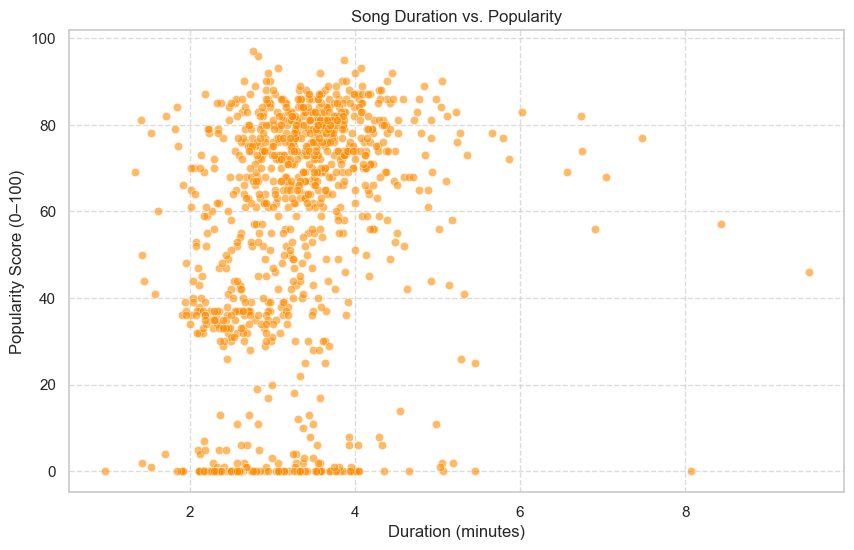

In [17]:
# 3. SCATTER PLOT

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='duration_min',
    y='popularity',
    data=df,
    alpha=0.6,
    color='darkorange'
)
plt.title('Song Duration vs. Popularity')
plt.xlabel('Duration (minutes)')
plt.ylabel('Popularity Score (0–100)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

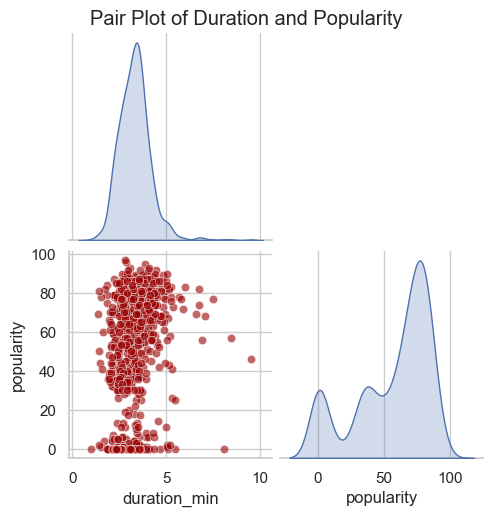

In [18]:
# 4. PAIR PLOT

key_features = ['duration_min', 'popularity']

sns.pairplot(
    df[key_features],
    diag_kind='kde',
    corner=True,
    plot_kws={'alpha': 0.6, 'color': '#990000'}
)

plt.suptitle('Pair Plot of Duration and Popularity', y=1.02)
plt.show()

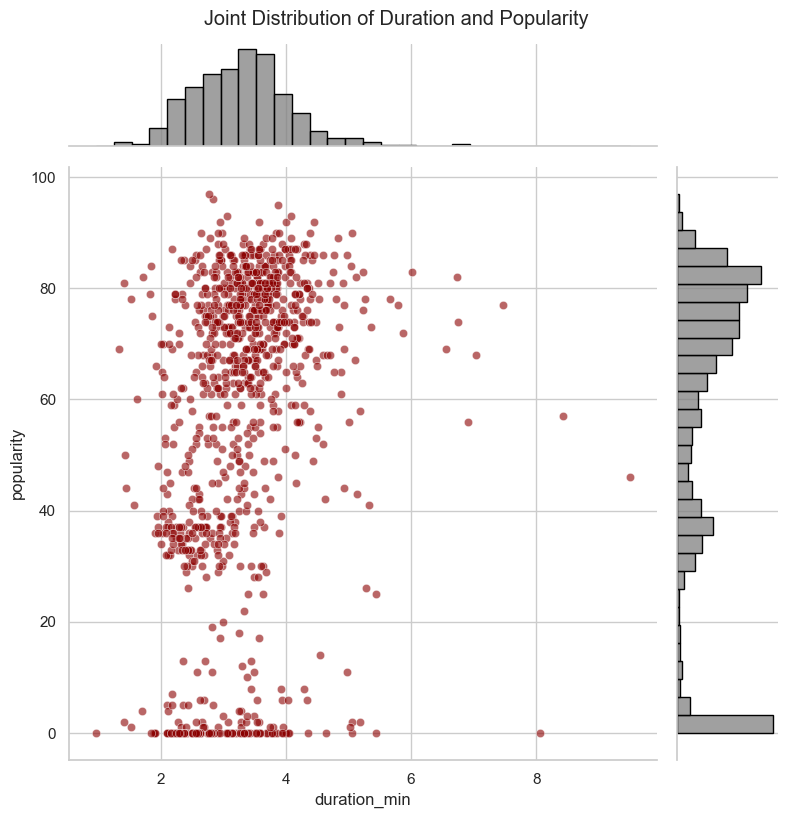

In [19]:
# 5. JOINT PLOT

sns.jointplot(
    x='duration_min',
    y='popularity',
    data=df,
    kind='scatter',
    height=8,
    marginal_kws={'bins': 30, 'color': 'gray', 'edgecolor': 'black'},
    joint_kws={'alpha': 0.6, 'color': 'darkred'}
)

plt.suptitle('Joint Distribution of Duration and Popularity', y=1.02)
plt.show()

In [20]:
!pip install matplotlib pillow pandas --quiet


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [21]:
# Step 1: Imports
import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

In [22]:
# Step 2: Load dataset (FIXED PATH)
df = pd.read_csv("spotify_dataset/spotify_top_1000_tracks.csv")

# Convert release_date to datetime
df["release_date"] = pd.to_datetime(df["release_date"], errors="coerce")

# Extract year
df["year"] = df["release_date"].dt.year

# Drop missing years
df = df.dropna(subset=["year"])

In [23]:
# Step 3: Compute average popularity per year
yearly_popularity = (
    df.groupby("year")["popularity"]
    .mean()
    .reset_index()
    .sort_values("year")
)

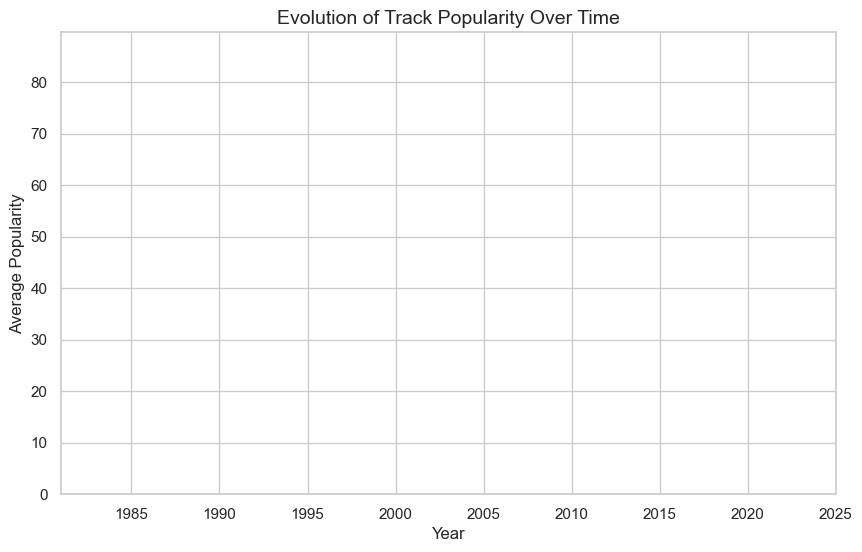

In [24]:
# Step 4: Initialize figure
fig, ax = plt.subplots(figsize=(10, 6))

ax.set_xlim(yearly_popularity["year"].min(), yearly_popularity["year"].max())
ax.set_ylim(0, yearly_popularity["popularity"].max() + 5)

line, = ax.plot([], [], lw=2.5, color="royalblue")

ax.set_title("Evolution of Track Popularity Over Time", fontsize=14)
ax.set_xlabel("Year")
ax.set_ylabel("Average Popularity")
ax.grid(True)

In [25]:
# Step 5: Animation function
def animate(i):
    x = yearly_popularity["year"][:i]
    y = yearly_popularity["popularity"][:i]
    line.set_data(x, y)
    return line,

In [26]:
# Step 6: Create animation
ani = FuncAnimation(
    fig,
    animate,
    frames=len(yearly_popularity),
    interval=100,
    repeat=False
)

In [27]:

# Step 7: Save GIF
gif_path = "yearly_popularity_trend.gif"
ani.save(gif_path, writer=PillowWriter(fps=10))

print("GIF saved successfully at:", gif_path)

GIF saved successfully at: yearly_popularity_trend.gif


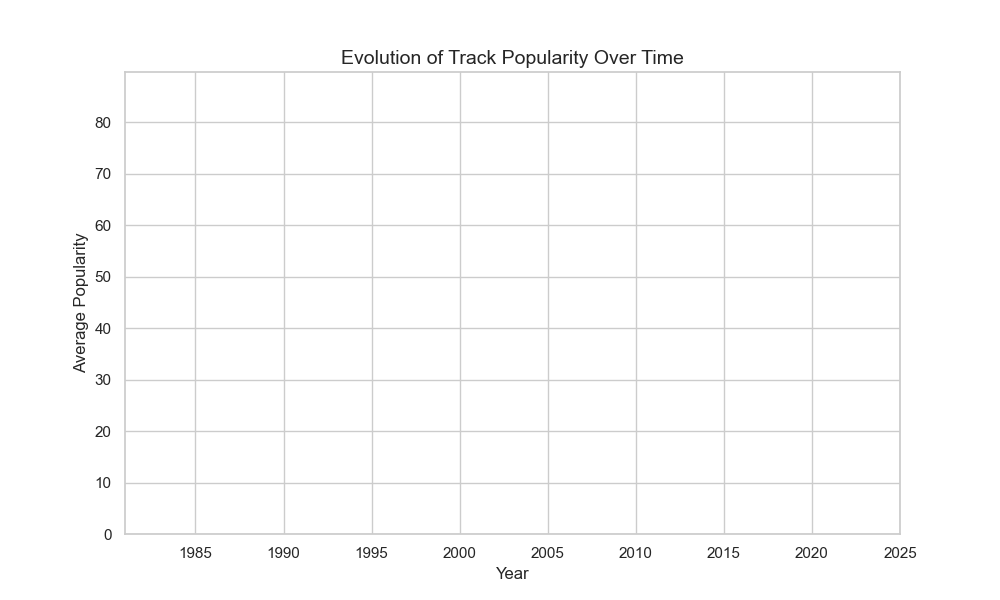

In [28]:
# Step 8: Display animation (inside notebook)
from IPython.display import Image
Image(filename=gif_path)

In [29]:
#0

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

student_name = "Joyce Anne A. Jano"
student_id = "20251312"

id_num = int(student_id[-3:])

color1 = f"#{(id_num * 7) % 256:02x}{(id_num * 3) % 256:02x}{(id_num * 5) % 256:02x}"
color2 = f"#{(id_num * 2) % 256:02x}{(id_num * 9) % 256:02x}{(id_num * 4) % 256:02x}"

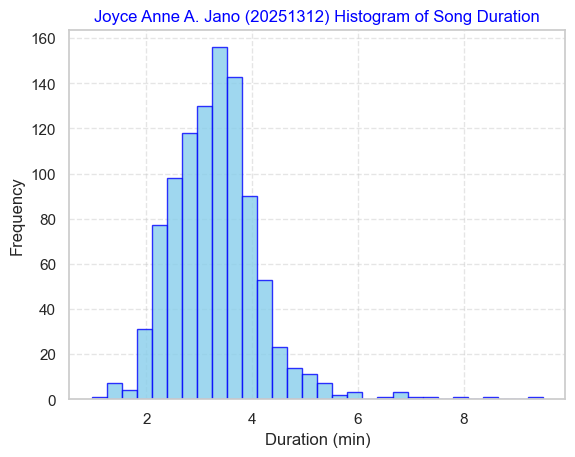

In [30]:
#1 - HISTOGRAM

if 'duration_ms' in df.columns:
    df['duration_min'] = df['duration_ms'] / 60000

elif 'duration' in df.columns:
    df['duration_min'] = df['duration'] / 60000

# Plot
df['duration_min'].plot(
    kind='hist',
    bins=30,
    color='skyblue',
    edgecolor='blue',
    alpha=0.8
)

plt.title(
    f"{student_name} ({student_id}) Histogram of Song Duration",
    color='blue'
)

plt.xlabel('Duration (min)')

plt.ylabel('Frequency')

plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

C:\Users\joyce\AppData\Local\Temp\ipykernel_44228\257005395.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\joyce\AppData\Local\Temp\ipykernel_44228\257005395.py:15: UserWarning: 
The palette list has fewer values (4) than needed (5) and will cycle, which may produce an uninterpretable plot.
  sns.boxplot(


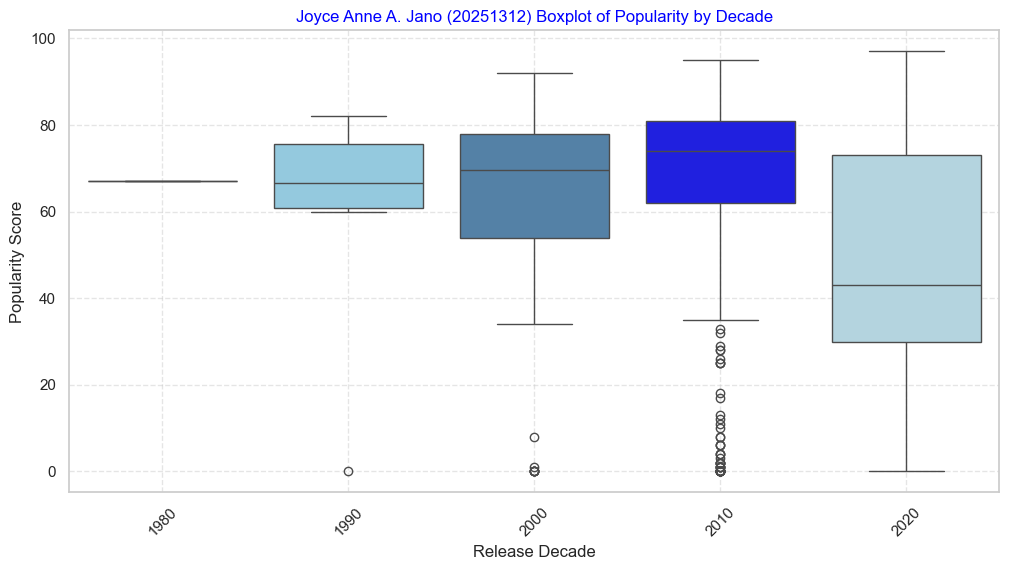

In [31]:
#2 - BOXPLOT

import seaborn as sns
import matplotlib.pyplot as plt

# Decade Column
df['decade'] = (df['release_date'].dt.year // 10) * 10

# Blue palette
blue_palette = ["#add8e6", "#87ceeb", "#4682b4", "#0000ff"]

# Plot
plt.figure(figsize=(12, 6))

sns.boxplot(
    x='decade',
    y='popularity',
    data=df,
    palette=blue_palette,
    legend=False
)

plt.title(
    f"{student_name} ({student_id}) Boxplot of Popularity by Decade",
    color='blue'
)

plt.xlabel('Release Decade')

plt.ylabel('Popularity Score')

plt.xticks(rotation=45)

plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

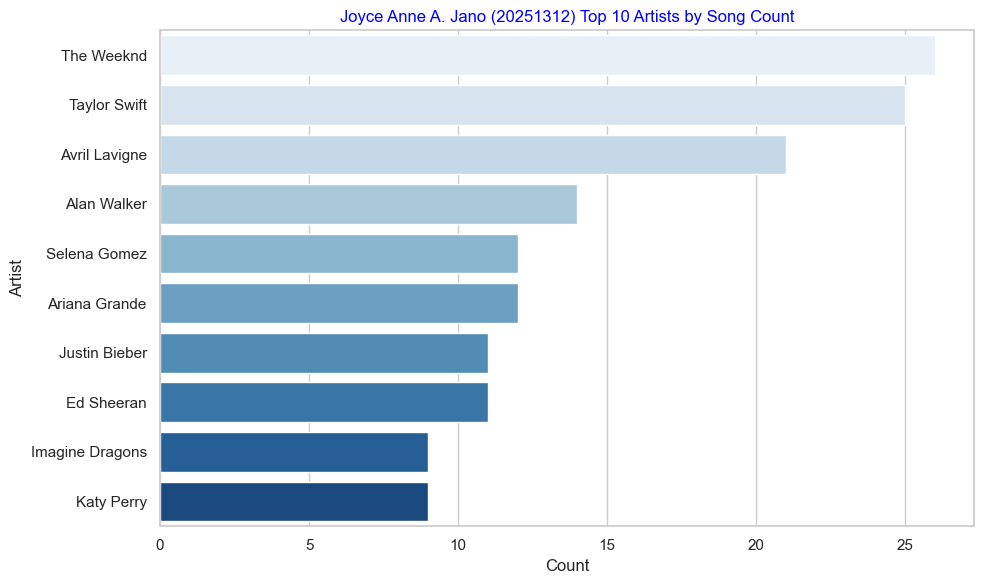

In [32]:
#3 - HORIZONTAL BAR

# Count top 10 artists
top_artists = df['artist'].value_counts().head(10).reset_index()

top_artists.columns = ['artist', 'count']

# Plot
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_artists,
    y='artist',
    x='count',
    hue='artist',
    palette='Blues',
    dodge=False,
    legend=False
)

plt.title(
    f"{student_name} ({student_id}) Top 10 Artists by Song Count",
    color='blue'
)

plt.xlabel("Count")

plt.ylabel("Artist")

plt.tight_layout()

plt.show()

In [33]:
# Create duration in minutes

if 'duration_ms' in df.columns:

    df['duration_min'] = df['duration_ms'] / 60000

elif 'duration_min' in df.columns:

    df['duration_min'] = df['duration_min']

elif 'duration' in df.columns:

    df['duration_min'] = df['duration'] / 60000

# Remove missing values
df = df.dropna(subset=['duration_min'])

print(df[['duration_min']].head())

   duration_min
0      3.869767
1      3.840883
2      3.182667
3      3.980083
4      3.432433


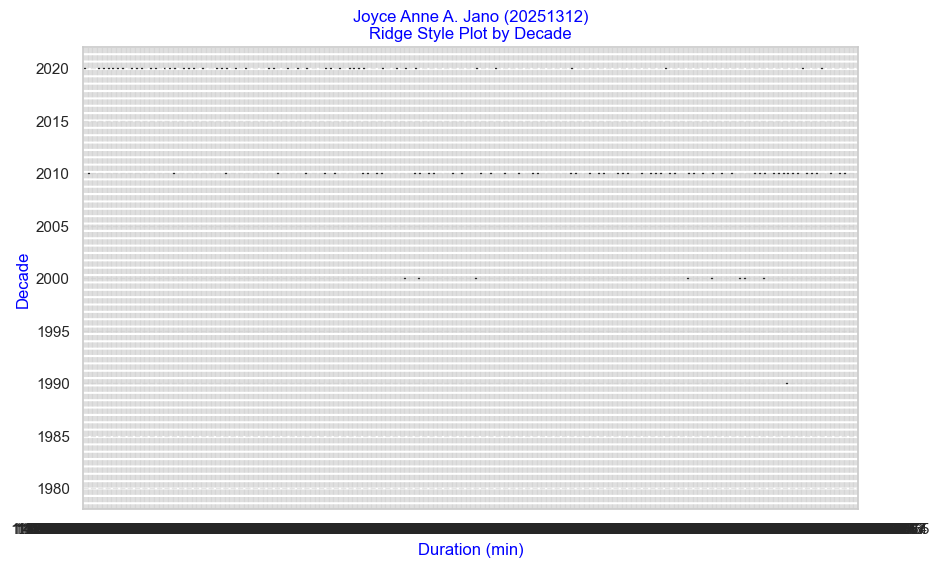

In [34]:
plt.figure(figsize=(10, 6))

sns.violinplot(
    data=df,
    x='duration_min',
    y='decade',
    hue='decade',
    palette='Blues',
    inner='box',
    linewidth=1,
    density_norm='width',
    legend=False
)

plt.title(
    f"{student_name} ({student_id})\nRidge Style Plot by Decade",
    color='blue'
)

plt.xlabel("Duration (min)", color='blue')

plt.ylabel("Decade", color='blue')

plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

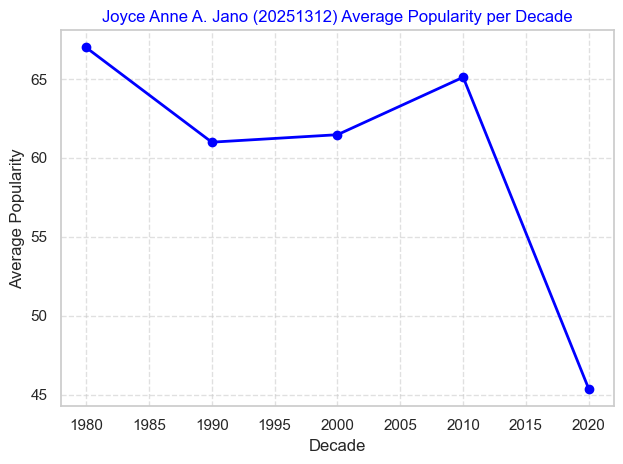

In [35]:
#5 - LINE GRAPH

avg_pop = df.groupby('decade')['popularity'].mean()

plt.plot(
    avg_pop.index,
    avg_pop.values,
    color='blue',
    marker='o',
    linewidth=2
)

plt.title(
    f"{student_name} ({student_id}) Average Popularity per Decade",
    color='blue'
)

plt.xlabel("Decade")

plt.ylabel("Average Popularity")

plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()

plt.show()

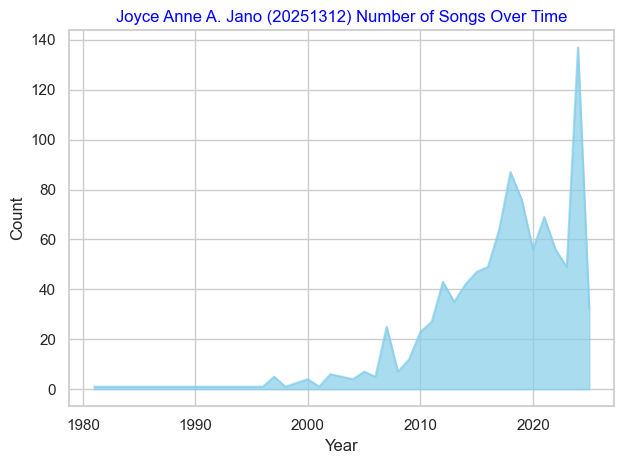

In [36]:
#6 - AREA PLOT

if 'release_date' in df.columns:

    df['release_year'] = pd.to_datetime(
        df['release_date'],
        errors='coerce'
    ).dt.year

else:
    print("⚠️ 'release_date' column not found")

df = df.dropna(subset=['release_year'])

count_by_year = df['release_year'].value_counts().sort_index()

count_by_year.plot(
    kind='area',
    color='skyblue',
    alpha=0.7
)

plt.title(
    f"{student_name} ({student_id}) Number of Songs Over Time",
    color='blue'
)

plt.xlabel("Year")

plt.ylabel("Count")

plt.tight_layout()

plt.show()

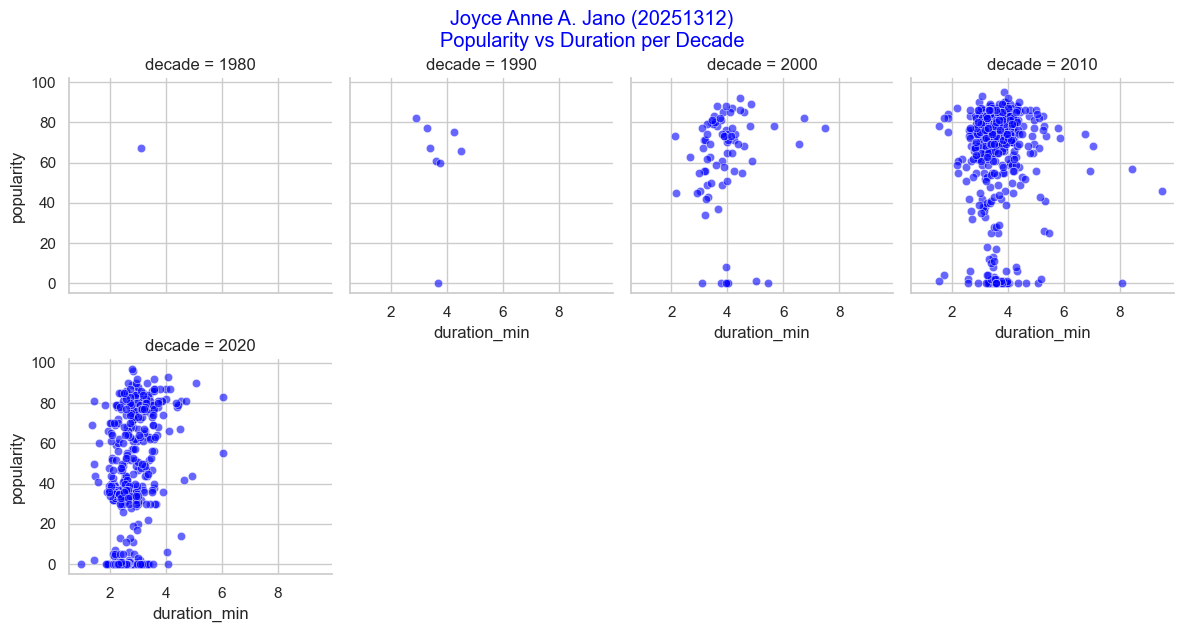

In [37]:
#7 - FACET SCATTER

import seaborn as sns
import matplotlib.pyplot as plt

g = sns.FacetGrid(df, col='decade', col_wrap=4, height=3)

g.map_dataframe(
    sns.scatterplot,
    x='duration_min',
    y='popularity',
    color='blue',
    alpha=0.6
)

g.fig.suptitle(
    f"{student_name} ({student_id})\nPopularity vs Duration per Decade",
    color='blue',
    y=1.05
)

plt.show()

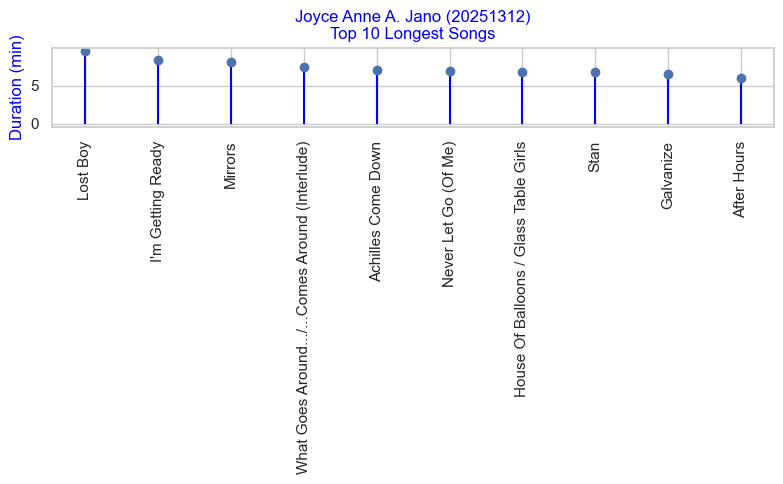

In [38]:
#8 - LOLLIPOP CHART

import matplotlib.pyplot as plt

longest = df.nlargest(10, 'duration_min')

plt.figure(figsize=(8,5))

plt.stem(
    longest['track_name'],
    longest['duration_min'],
    linefmt='blue',
    markerfmt='bo',
    basefmt=' '
)

plt.xticks(rotation=90)

plt.title(
    f"{student_name} ({student_id})\nTop 10 Longest Songs",
    color='blue'
)

plt.ylabel("Duration (min)", color='blue')

plt.tight_layout()

plt.show()

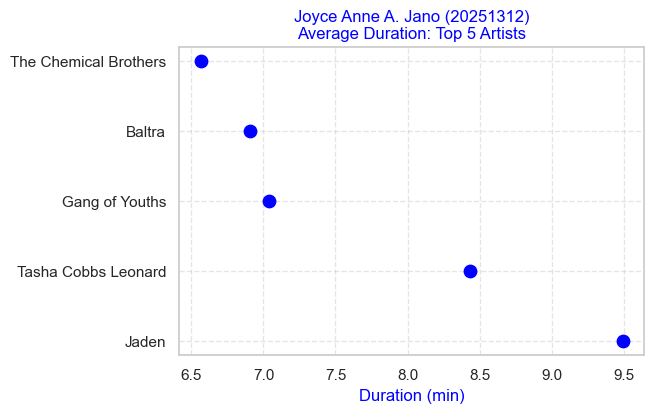

In [39]:
#9 - DOT CHART

import matplotlib.pyplot as plt

avg_duration = df.groupby('artist')['duration_min'].mean().nlargest(5)

plt.figure(figsize=(6,4))

plt.scatter(
    avg_duration.values,
    avg_duration.index,
    color='blue',
    s=80
)

plt.title(
    f"{student_name} ({student_id})\nAverage Duration: Top 5 Artists",
    color='blue'
)

plt.xlabel("Duration (min)", color='blue')

plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

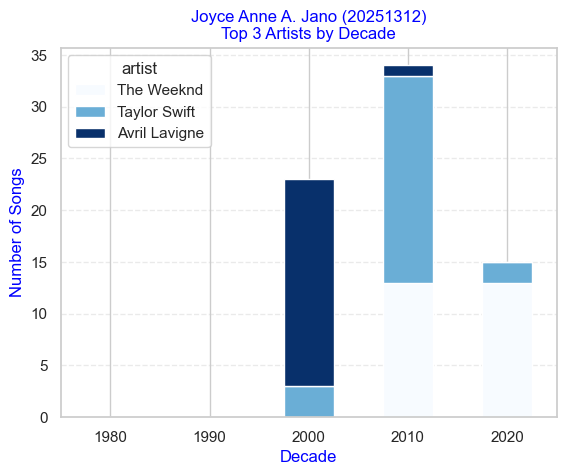

In [40]:
#10 - STACKED BAR CHART

import matplotlib.pyplot as plt

crosstab = pd.crosstab(df['decade'], df['artist'])

top3 = df['artist'].value_counts().head(3).index

crosstab[top3].plot(
    kind='bar',
    stacked=True,
    colormap='Blues'
)

plt.title(
    f"{student_name} ({student_id})\nTop 3 Artists by Decade",
    color='blue'
)

plt.ylabel("Number of Songs", color='blue')

plt.xlabel("Decade", color='blue')

plt.xticks(rotation=0)

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.show()

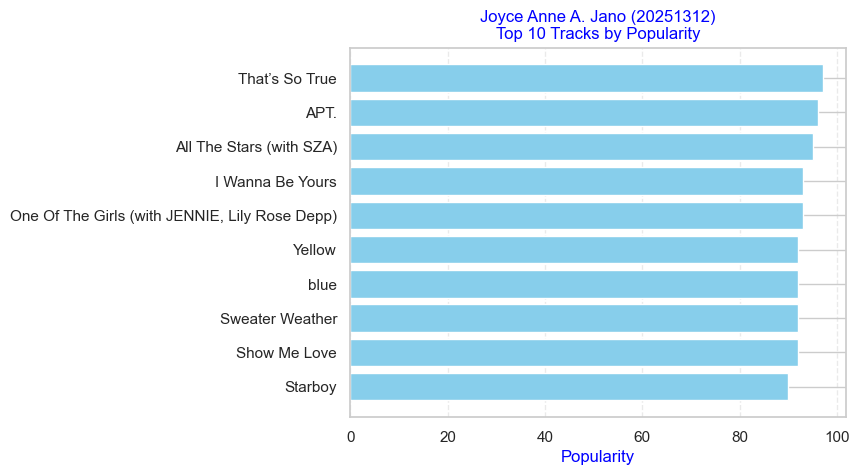

In [41]:
#11 - HORIZONTAL BAR

top_tracks = df.nlargest(10, 'popularity')

plt.barh(
    top_tracks['track_name'],
    top_tracks['popularity'],
    color='skyblue'
)

plt.xlabel("Popularity", color='blue')

plt.title(
    f"{student_name} ({student_id})\nTop 10 Tracks by Popularity",
    color='blue'
)

plt.gca().invert_yaxis()

plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.show()

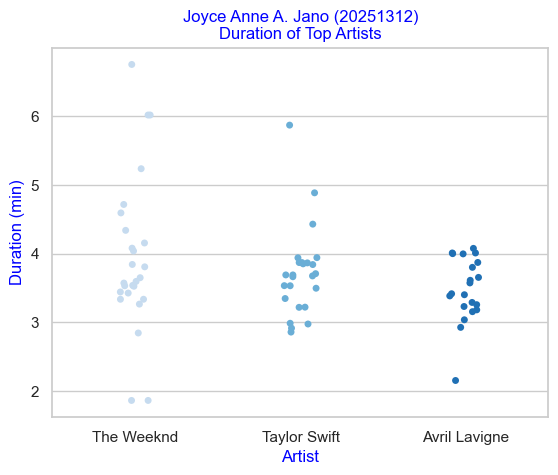

In [42]:
#12 - STRIP PLOT

import seaborn as sns

top_artists = df['artist'].value_counts().head(3).index

sns.stripplot(
    data=df[df['artist'].isin(top_artists)],
    x='artist',
    y='duration_min',
    hue='artist',
    palette='Blues',
    legend=False
)

plt.title(
    f"{student_name} ({student_id})\nDuration of Top Artists",
    color='blue'
)

plt.xlabel("Artist", color='blue')

plt.ylabel("Duration (min)", color='blue')

plt.show()

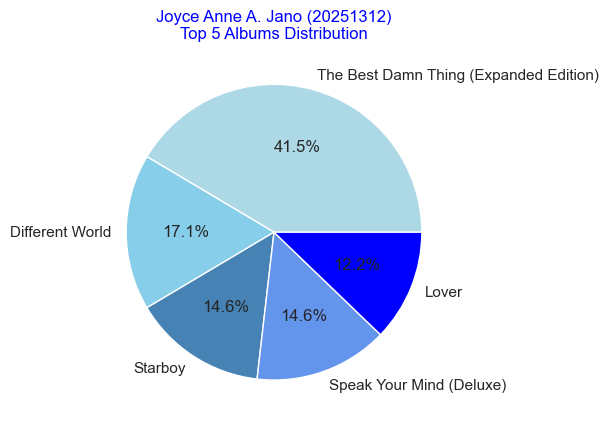

In [43]:
#13 - PIE CHART

top_albums = df['album'].value_counts().head(5)

colors = ['#add8e6', '#87ceeb', '#4682b4', '#6495ed', '#0000ff']

plt.pie(
    top_albums,
    labels=top_albums.index,
    autopct='%1.1f%%',
    colors=colors
)

plt.title(
    f"{student_name} ({student_id})\nTop 5 Albums Distribution",
    color='blue'
)

plt.show()

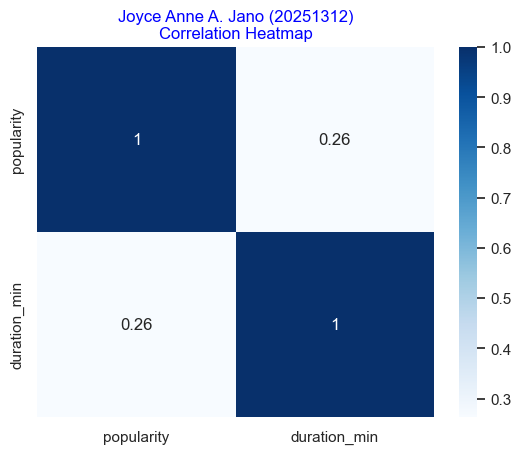

In [44]:
#14 - HEATMAP

import seaborn as sns

numerical_cols = ['popularity', 'duration_min']

df_numeric = df[numerical_cols].dropna()

sns.heatmap(
    df_numeric.corr(),
    annot=True,
    cmap='Blues'
)

plt.title(
    f"{student_name} ({student_id})\nCorrelation Heatmap",
    color='blue'
)

plt.show()

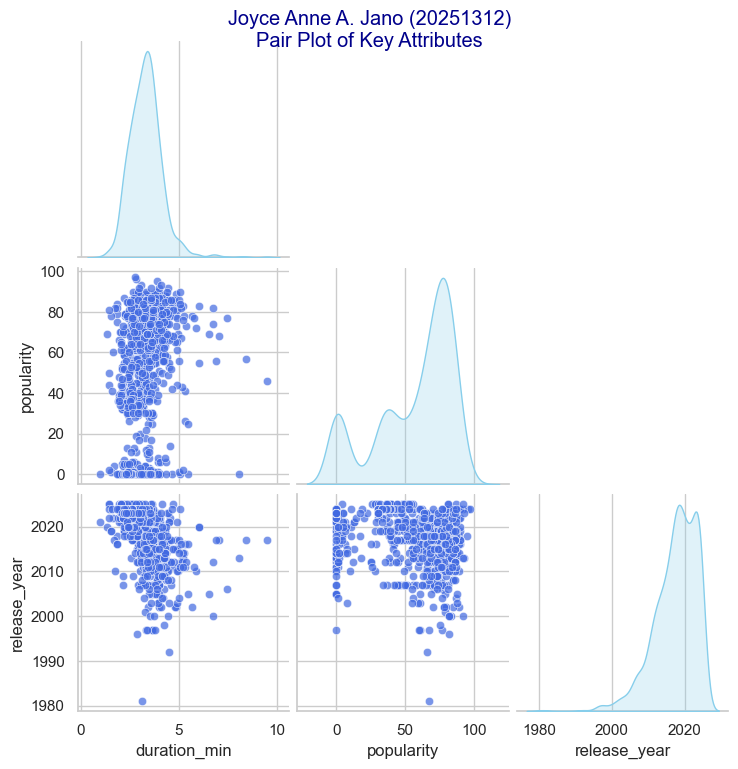

In [45]:
#15 - PAIR PLOT

import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(
    df[['duration_min', 'popularity', 'release_year']],
    diag_kind='kde',
    corner=True,
    plot_kws={'color': 'royalblue', 'alpha': 0.7},
    diag_kws={'fill': True, 'color': 'skyblue'}
)

plt.suptitle(
    f"{student_name} ({student_id})\nPair Plot of Key Attributes",
    y=1.02,
    color='darkblue'
)

plt.show()

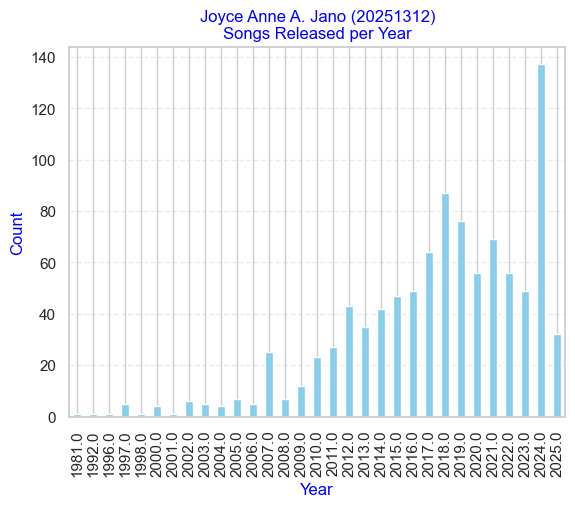

In [50]:
#16 - BAR PLOT

df['year'].value_counts().sort_index().plot(
    kind='bar',
    color='skyblue'
)

plt.title(
    f"{student_name} ({student_id})\nSongs Released per Year",
    color='blue'
)

plt.xlabel("Year", color='blue')

plt.ylabel("Count", color='blue')

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.show()

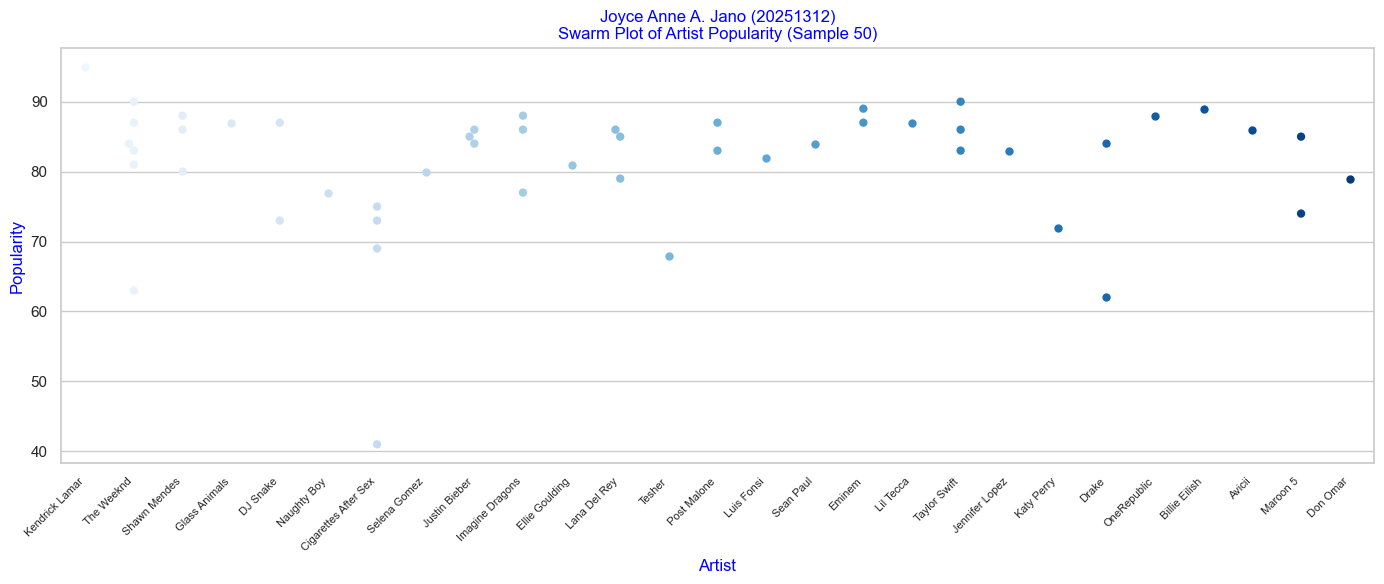

In [51]:
#17 - SWARM PLOT

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

sns.swarmplot(
    data=df.head(50),
    x='artist',
    y='popularity',
    hue='artist',
    palette='Blues',
    legend=False,
    size=6
)

plt.title(
    f"{student_name} ({student_id})\nSwarm Plot of Artist Popularity (Sample 50)",
    color='blue'
)

plt.xlabel("Artist", color='blue')

plt.ylabel("Popularity", color='blue')

plt.xticks(rotation=45, ha='right', fontsize=8)

plt.tight_layout()

plt.show()

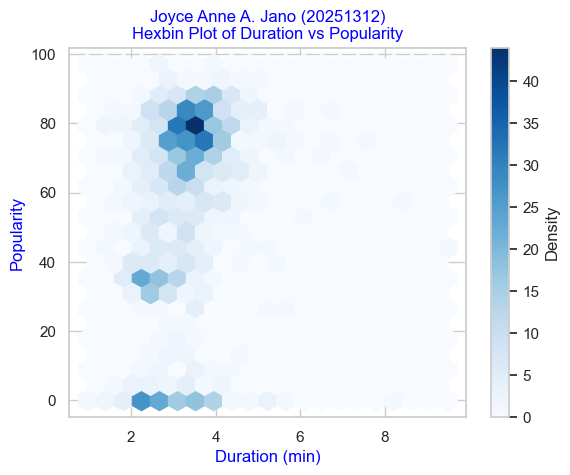

In [52]:
#18 - HEXBIN PLOT

plt.hexbin(
    df['duration_min'],
    df['popularity'],
    gridsize=20,
    cmap='Blues'
)

plt.colorbar(label='Density')

plt.xlabel("Duration (min)", color='blue')

plt.ylabel("Popularity", color='blue')

plt.title(
    f"{student_name} ({student_id})\nHexbin Plot of Duration vs Popularity",
    color='blue'
)

plt.show()

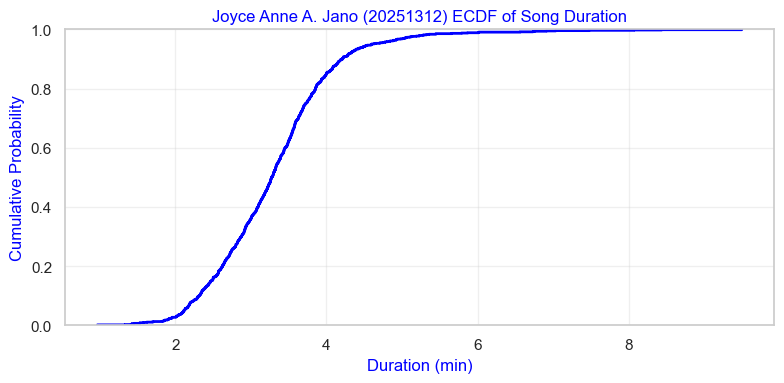

In [53]:
#19 - ECDF PLOT

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))

sns.ecdfplot(
    data=df,
    x='duration_min',
    color='blue',
    linewidth=2
)

plt.title(
    f"{student_name} ({student_id}) ECDF of Song Duration",
    color='blue'
)

plt.xlabel("Duration (min)", color='blue')

plt.ylabel("Cumulative Probability", color='blue')

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

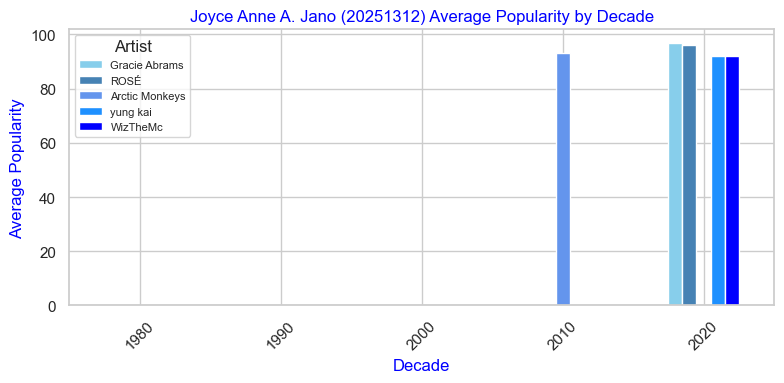

In [54]:
#20 - GROUPED BAR PLOT

import matplotlib.pyplot as plt

avg_artist_decade = df.groupby(
    ['decade', 'artist']
)['popularity'].mean().unstack()

top_artists = avg_artist_decade.mean().sort_values(
    ascending=False
).head(5).index

avg_artist_decade = avg_artist_decade[top_artists]

plt.figure(figsize=(8, 4))

avg_artist_decade.plot(
    kind='bar',
    color=['#87ceeb', '#4682b4', '#6495ed', '#1e90ff', '#0000ff'],
    ax=plt.gca()
)

plt.title(
    f"{student_name} ({student_id}) Average Popularity by Decade",
    color='blue'
)

plt.xlabel("Decade", color='blue')

plt.ylabel("Average Popularity", color='blue')

plt.xticks(rotation=45)

plt.legend(title="Artist", fontsize=8)

plt.tight_layout()

plt.show()